# Fine-tune Qwen3.5-9B for ASR Correction

Quick LoRA fine-tune on high-quality correction data only.
- **Base model**: `mlx-community/Qwen3.5-9B-MLX-4bit`
- **Adapters saved to**: `asr_correction/adapters_qwen35/`
- **Restore point**: `git checkout 66a43c9 -- asr_correction/config.py` to revert to no-adapter mode

## Step 1: Filter Training Data (keep only good examples)

In [8]:
import json
from pathlib import Path

ROOT = Path('.').resolve().parent
data_dir = ROOT / 'data' / 'collected_data'
output_dir = ROOT / 'data' / 'finetune_qwen35'
output_dir.mkdir(parents=True, exist_ok=True)

# Load all training data
with open(data_dir / 'train.jsonl') as f:
    train_all = [json.loads(l) for l in f if l.strip()]
with open(data_dir / 'valid.jsonl') as f:
    valid_all = [json.loads(l) for l in f if l.strip()]

print(f'Original: {len(train_all)} train, {len(valid_all)} valid')

Original: 16082 train, 2838 valid


In [9]:
def is_good_example(example):
    """Filter for high-quality correction examples."""
    m = example.get('metadata', {})
    
    # Keep negative examples (model should learn NOT to change correct text)
    if m.get('is_negative'):
        return True
    
    error = m.get('error_found', '')
    term = m.get('term', '')
    
    if not error or not term:
        return False
    
    # Skip: error == term (no actual correction)
    if error.lower().strip('.,!?\'" ') == term.lower().strip('.,!?\'" '):
        return False
    
    # Skip trivial punctuation-only changes
    if error.replace(',', '').replace('.', '').lower() == term.replace(',', '').replace('.', '').lower():
        return False
    
    # Skip very short errors (likely noise)
    if len(error) < 2 or len(term) < 2:
        return False
    
    # Keep domain-specific corrections (the important ones)
    category = m.get('category', '')
    good_categories = {'person_name', 'product_name', 'company_name', 'tech_term', 
                       'ai_model', 'tech_library', 'domain_term', 'proper_noun',
                       'tech_acronym', 'feature', 'custom'}
    if category in good_categories:
        return True
    
    # For content_word: only keep if the change is meaningful
    if category == 'content_word':
        # Skip trivial grammar fixes
        if abs(len(error) - len(term)) <= 2 and error[:3].lower() == term[:3].lower():
            return False
        return True
    
    return m.get('applied', False)

train_good = [e for e in train_all if is_good_example(e)]
valid_good = [e for e in valid_all if is_good_example(e)]

print(f'Filtered: {len(train_good)} train, {len(valid_good)} valid')
print(f'Removed: {len(train_all) - len(train_good)} train, {len(valid_all) - len(valid_good)} valid')

# Show category breakdown
cats = {}
for e in train_good:
    c = e.get('metadata', {}).get('category', 'unknown')
    cats[c] = cats.get(c, 0) + 1
print(f'\nCategories: {json.dumps(cats, indent=2)}')

Filtered: 8562 train, 1497 valid
Removed: 7520 train, 1341 valid

Categories: {
  "content_word": 3751,
  "product_name": 603,
  "feature": 415,
  "tech_term": 757,
  "person_name": 1010,
  "business_term": 148,
  "ai_model": 329,
  "custom": 133,
  "business_metric": 79,
  "company_name": 418,
  "proper_noun": 37,
  "compliance": 244,
  "tech_acronym": 181,
  "platform": 62,
  "tech_library": 66,
  "domain_term": 61,
  "cloud_service": 16,
  "place_name": 71,
  "organization": 34,
  "region": 31,
  "country": 46,
  "financial_term": 18,
  "product_tier": 19,
  "tool_name": 17,
  "metric": 16
}


In [10]:
# Show some examples
print('--- Sample filtered corrections ---')
for e in train_good[::len(train_good)//10][:10]:
    m = e['metadata']
    if m.get('is_negative'):
        print(f'  [NEGATIVE] "{m.get("term","?")}" is correct, no change needed')
    else:
        print(f'  "{m.get("error_found","?")}" → "{m.get("term","?")}" ({m.get("category","?")})')

--- Sample filtered corrections ---
  "best" → "does" (content_word)
  "speed" → "speech" (tech_term)
  [NEGATIVE] "know" is correct, no change needed
  "quadrant" → "Qdrant" (tech_term)
  [NEGATIVE] "this," is correct, no change needed
  [NEGATIVE] "Fireworks?" is correct, no change needed
  [NEGATIVE] "closing" is correct, no change needed
  [NEGATIVE] "about," is correct, no change needed
  "SOC" → "SOC 2" (compliance)
  [NEGATIVE] "little" is correct, no change needed


In [ ]:
# Save filtered data
with open(output_dir / 'train.jsonl', 'w') as f:
    for e in train_good:
        f.write(json.dumps(e, ensure_ascii=False) + '\n')

with open(output_dir / 'valid.jsonl', 'w') as f:
    for e in valid_good:
        f.write(json.dumps(e, ensure_ascii=False) + '\n')

print(f'Saved to {output_dir}/')
print(f'  train.jsonl: {len(train_good)} examples')
print(f'  valid.jsonl: {len(valid_good)} examples')

## Step 2: Fine-tune with LoRA

In [12]:
import gc
import mlx.core as mx
from mlx_lm import load
from mlx_lm.tuner import train as lora_train
from mlx_lm.tuner.datasets import load_dataset
from mlx_lm.tuner.trainer import TrainingArgs
from mlx_lm.tuner.utils import linear_to_lora_layers
from mlx.utils import tree_flatten
import mlx.optimizers as optim
from types import SimpleNamespace

MODEL_NAME = 'mlx-community/Qwen3.5-9B-MLX-4bit'
ADAPTER_PATH = ROOT / 'asr_correction' / 'adapters_qwen35'
ADAPTER_PATH.mkdir(parents=True, exist_ok=True)

# Hyperparameters — conservative to avoid overfitting
ITERATIONS = 1000        # start small, can increase
BATCH_SIZE = 4
LEARNING_RATE = 1e-5
LORA_RANK = 8            # smaller rank = less overfitting
LORA_LAYERS = 8
LORA_KEYS = ['self_attn.q_proj', 'self_attn.v_proj']

print(f'Model: {MODEL_NAME}')
print(f'Adapters: {ADAPTER_PATH}')
print(f'Iterations: {ITERATIONS}, Batch: {BATCH_SIZE}, LR: {LEARNING_RATE}')
print(f'LoRA: rank={LORA_RANK}, layers={LORA_LAYERS}')

Model: mlx-community/Qwen3.5-9B-MLX-4bit
Adapters: /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/asr_correction/adapters_qwen35
Iterations: 1000, Batch: 4, LR: 1e-05
LoRA: rank=8, layers=8


In [13]:
# Load model
print('Loading model...')
model, tokenizer = load(MODEL_NAME)
print('Model loaded!')

Loading model...


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Model loaded!


In [14]:
# Load filtered dataset
dataset_args = SimpleNamespace(
    data=str(output_dir),
    hf_dataset=False,
    train=True,
    test=False,
)
train_set, valid_set, _ = load_dataset(dataset_args, tokenizer)

# Wrap for tokenization
class TokenizedDataset:
    def __init__(self, chat_dataset):
        self._ds = chat_dataset
    def __len__(self):
        return len(self._ds)
    def __getitem__(self, idx):
        return self._ds.process(self._ds._data[idx])

train_set = TokenizedDataset(train_set)
valid_set = TokenizedDataset(valid_set)
print(f'Dataset: {len(train_set)} train, {len(valid_set)} valid')

Dataset: 8562 train, 1497 valid


In [15]:
# Apply LoRA
lora_config = {
    'rank': LORA_RANK,
    'scale': float(LORA_RANK),
    'dropout': 0.0,
    'keys': LORA_KEYS,
}
linear_to_lora_layers(model, LORA_LAYERS, lora_config)

model.freeze()
model.unfreeze(keys=['lora_a', 'lora_b'])

trainable = tree_flatten(model.trainable_parameters())
print(f'Trainable LoRA parameters: {len(trainable)}')

Trainable LoRA parameters: 8


In [ ]:
# Train!
import time

adapter_file = str(ADAPTER_PATH / 'adapters.safetensors')

training_args = TrainingArgs(
    batch_size=BATCH_SIZE,
    iters=ITERATIONS,
    steps_per_report=10,
    steps_per_eval=200,
    steps_per_save=200,
    val_batches=25,
    adapter_file=adapter_file,
    grad_checkpoint=True,
)

optimizer = optim.Adam(learning_rate=LEARNING_RATE)

print(f'Starting training for {ITERATIONS} iterations...')
print(f'Saving adapters to: {adapter_file}')
start = time.time()

lora_train(
    model=model,
    optimizer=optimizer,
    train_dataset=train_set,
    val_dataset=valid_set,
    args=training_args,
)

elapsed = time.time() - start
print(f'\nDone! Training took {elapsed/60:.1f} minutes')
print(f'Adapters saved to: {ADAPTER_PATH}')

## Step 3: Quick Test

In [19]:
# Reload model with new adapters
# del model, tokenizer
gc.collect()

model, tokenizer = load(MODEL_NAME, adapter_path=str(ADAPTER_PATH))
print('Model loaded with new adapters!')

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Model loaded with new adapters!


In [20]:
from mlx_lm import generate

# Test correction
test_cases = [
    {
        'asr': 'So we have been using GROC and Grok for our transcription pipeline',
        'vocab': ['Groq', 'ScreenApp', 'Kimi'],
    },
    {
        'asr': 'Sheldon and Andre are working on the Flashlight integration',
        'vocab': ['Sheldon', 'Andre', 'Flash Lite'],
    },
    {
        'asr': 'We should check the Cloudware and Pyanote configuration',
        'vocab': ['Cloudflare', 'pyannote'],
    },
]

system = 'You are an ASR transcript correction model. Given a noisy ASR transcript segment and context signals, detect errors in context-critical terms and output the corrected transcript with changes noted.'

for tc in test_cases:
    prompt = f"""Correct this ASR transcript segment using the provided context.

ASR transcript: {tc['asr']}
Custom vocabulary: {json.dumps(tc['vocab'])}
Category: tech_term
OCR hints: none available
Lip reading hint: null"""
    
    messages = [
        {'role': 'system', 'content': system},
        {'role': 'user', 'content': prompt},
    ]
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
        enable_thinking=False,
    )
    response = generate(model, tokenizer, prompt=formatted, max_tokens=256)
    print(f'Input:  {tc["asr"]}')
    print(f'Output: {response}')
    print('---')

Input:  So we have been using GROC and Grok for our transcription pipeline
Output: {"corrected": "So we have been using Groq and Grok for our transcription pipeline", "changes": ["GROC \u2192 Groq"], "confidence": 0.95, "need_lip": false}
---
Input:  Sheldon and Andre are working on the Flashlight integration
Output: {"corrected": "Sheldon and Andre are working on the Flashlight integration", "changes": [], "confidence": 0.99, "need_lip": false}
---
Input:  We should check the Cloudware and Pyanote configuration
Output: {"corrected": "We should check the Cloudflare and PyAnnote configuration", "changes": ["Cloudware \u2192 Cloudflare", "Pyanote \u2192 PyAnnote"], "confidence": 0.95, "need_lip": false}
---


## Step 4: Enable adapters in config

If the test looks good, update the config to use the new adapters:

```python
# In asr_correction/config.py, __post_init__:
# Change adapter auto-detection to point to adapters_qwen35/
```

Or revert if it's worse:
```bash
git checkout 66a43c9 -- asr_correction/config.py
```

## Step 5: Training Visualizations & Analysis

Graphs for the FYP report — training curves, data distributions, performance metrics.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import json
from pathlib import Path
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ── Parse training logs ──
train_log = [
    (10, 2.971), (20, 2.834), (30, 2.647), (40, 2.497), (50, 2.540),
    (60, 2.382), (70, 2.287), (80, 2.055), (90, 1.792), (100, 1.964),
    (110, 1.836), (120, 1.643), (130, 1.444), (140, 1.859), (150, 1.564),
    (160, 1.541), (170, 1.561), (180, 1.374), (190, 1.581), (200, 1.477),
    (210, 1.444), (220, 1.476), (230, 1.456), (240, 1.507), (250, 1.573),
    (260, 1.389), (270, 1.477), (280, 1.447), (290, 1.445), (300, 1.446),
    (310, 1.455), (320, 1.292), (330, 1.477), (340, 1.263), (350, 1.545),
    (360, 1.352), (370, 1.387), (380, 1.447), (390, 1.383), (400, 1.351),
    (410, 1.199), (420, 1.228), (430, 1.509), (440, 1.281), (450, 1.238),
    (460, 1.577), (470, 1.313), (480, 1.168), (490, 1.283), (500, 1.424),
    (510, 1.145), (520, 1.155), (530, 1.259), (540, 1.325), (550, 1.231),
    (560, 1.304), (570, 1.244), (580, 1.126), (590, 1.309), (600, 1.252),
    (610, 1.175), (620, 1.174), (630, 1.236), (640, 1.152), (650, 1.338),
    (660, 1.170), (670, 1.108), (680, 1.135), (690, 1.195), (700, 1.143),
    (710, 1.195), (720, 1.209), (730, 1.180), (740, 1.152), (750, 1.236),
    (760, 1.068), (770, 1.108), (780, 1.101), (790, 1.157), (800, 1.209),
    (810, 1.167), (820, 1.074), (830, 1.111), (840, 1.120), (850, 1.381),
    (860, 1.069), (870, 1.106), (880, 1.018), (890, 1.035), (900, 1.100),
    (910, 1.105), (920, 1.376), (930, 1.071), (940, 1.041), (950, 1.022),
    (960, 1.138), (970, 0.971), (980, 1.276), (990, 1.102), (1000, 1.002),
]

val_log = [
    (1, 2.979), (200, 1.547), (400, 1.450),
    (600, 1.218), (800, 1.074), (1000, 1.139),
]

tokens_sec_log = [
    (10, 170.5), (20, 137.6), (30, 117.2), (40, 98.3), (50, 116.5),
    (60, 146.8), (70, 148.3), (80, 137.0), (90, 119.0), (100, 139.4),
    (200, 133.5), (300, 102.6), (400, 111.7), (500, 136.4), (600, 131.7),
    (700, 143.8), (800, 191.2), (900, 212.1), (1000, 140.8),
]

peak_mem_log = [(10, 19.05), (20, 27.37), (50, 29.75), (540, 32.07)]

print("Training logs parsed successfully!")
print(f"  Train points: {len(train_log)}, Val points: {len(val_log)}")
print(f"  Total training time: 346.0 minutes (~5.8 hours)")

Training logs parsed successfully!
  Train points: 100, Val points: 6
  Total training time: 346.0 minutes (~5.8 hours)


### 5.1 Training & Validation Loss Curves

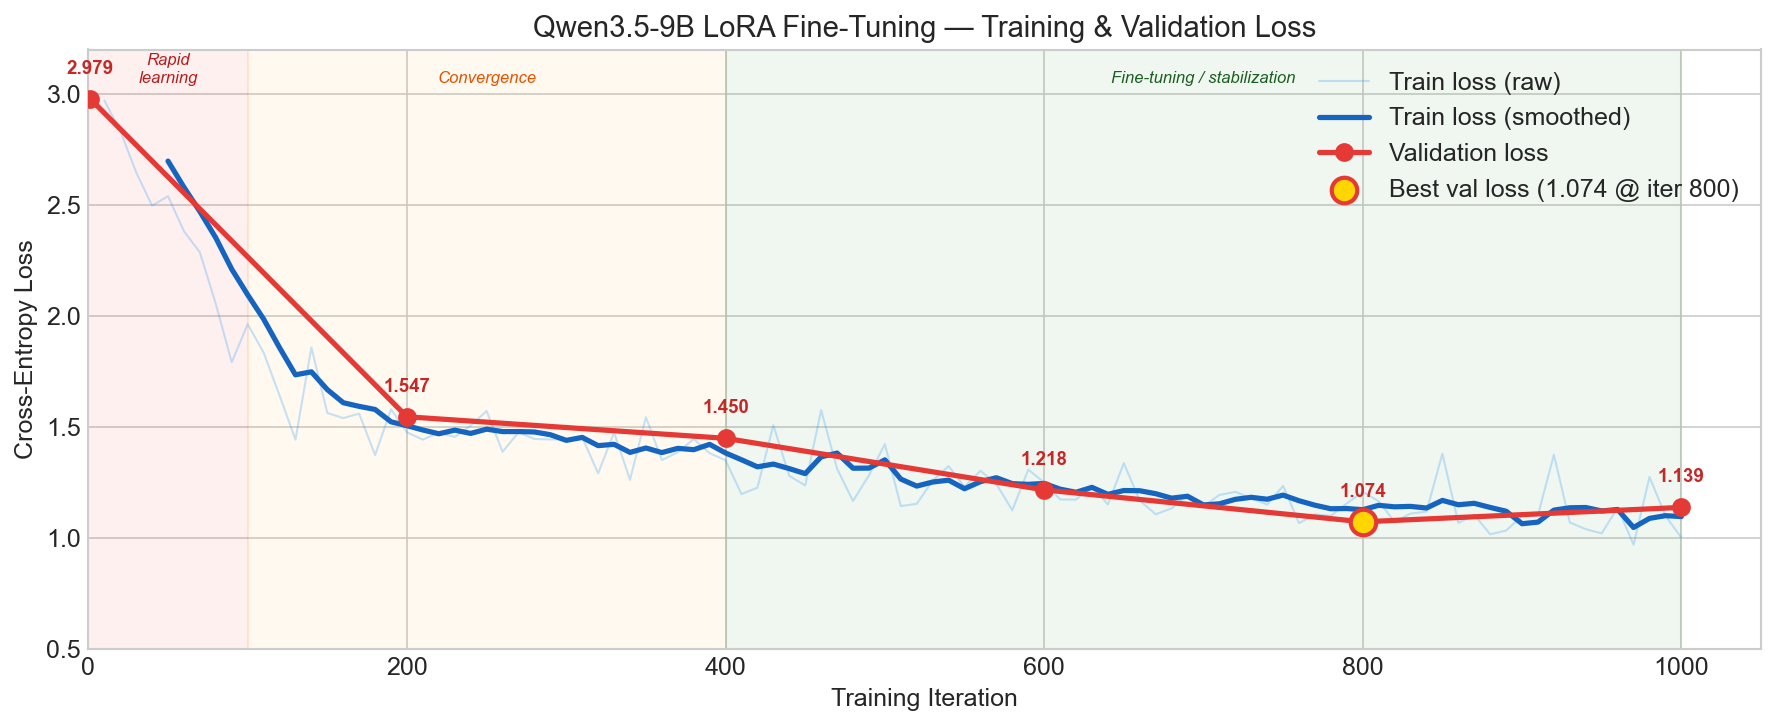

Saved: fig_loss_curves.png


In [2]:
# ── Figure 1: Training & Validation Loss ──
fig, ax = plt.subplots(figsize=(12, 5))

train_iters = [x[0] for x in train_log]
train_losses = [x[1] for x in train_log]
val_iters = [x[0] for x in val_log]
val_losses = [x[1] for x in val_log]

window = 5
train_smooth = np.convolve(train_losses, np.ones(window)/window, mode='valid')
train_smooth_iters = train_iters[window-1:]

ax.plot(train_iters, train_losses, alpha=0.25, color='#2196F3', linewidth=1, label='Train loss (raw)')
ax.plot(train_smooth_iters, train_smooth, color='#1565C0', linewidth=2.5, label='Train loss (smoothed)')
ax.plot(val_iters, val_losses, 'o-', color='#E53935', linewidth=2.5, markersize=8, label='Validation loss', zorder=5)

for it, vl in val_log:
    ax.annotate(f'{vl:.3f}', (it, vl), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=9, fontweight='bold', color='#C62828')

best_idx = np.argmin(val_losses)
ax.scatter([val_iters[best_idx]], [val_losses[best_idx]], s=150, color='#FFD600',
           edgecolors='#E53935', linewidths=2, zorder=10,
           label=f'Best val loss ({val_losses[best_idx]:.3f} @ iter {val_iters[best_idx]})')

ax.set_xlabel('Training Iteration')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Qwen3.5-9B LoRA Fine-Tuning \u2014 Training & Validation Loss')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_xlim(0, 1050)
ax.set_ylim(0.5, 3.2)

ax.axvspan(0, 100, alpha=0.06, color='red')
ax.axvspan(100, 400, alpha=0.06, color='orange')
ax.axvspan(400, 1000, alpha=0.06, color='green')
ax.text(50, 3.05, 'Rapid\nlearning', ha='center', fontsize=8, color='#B71C1C', style='italic')
ax.text(250, 3.05, 'Convergence', ha='center', fontsize=8, color='#E65100', style='italic')
ax.text(700, 3.05, 'Fine-tuning / stabilization', ha='center', fontsize=8, color='#1B5E20', style='italic')

plt.tight_layout()
plt.savefig('fig_loss_curves.png')
plt.show()
print("Saved: fig_loss_curves.png")

### 5.2 Training Data Distribution

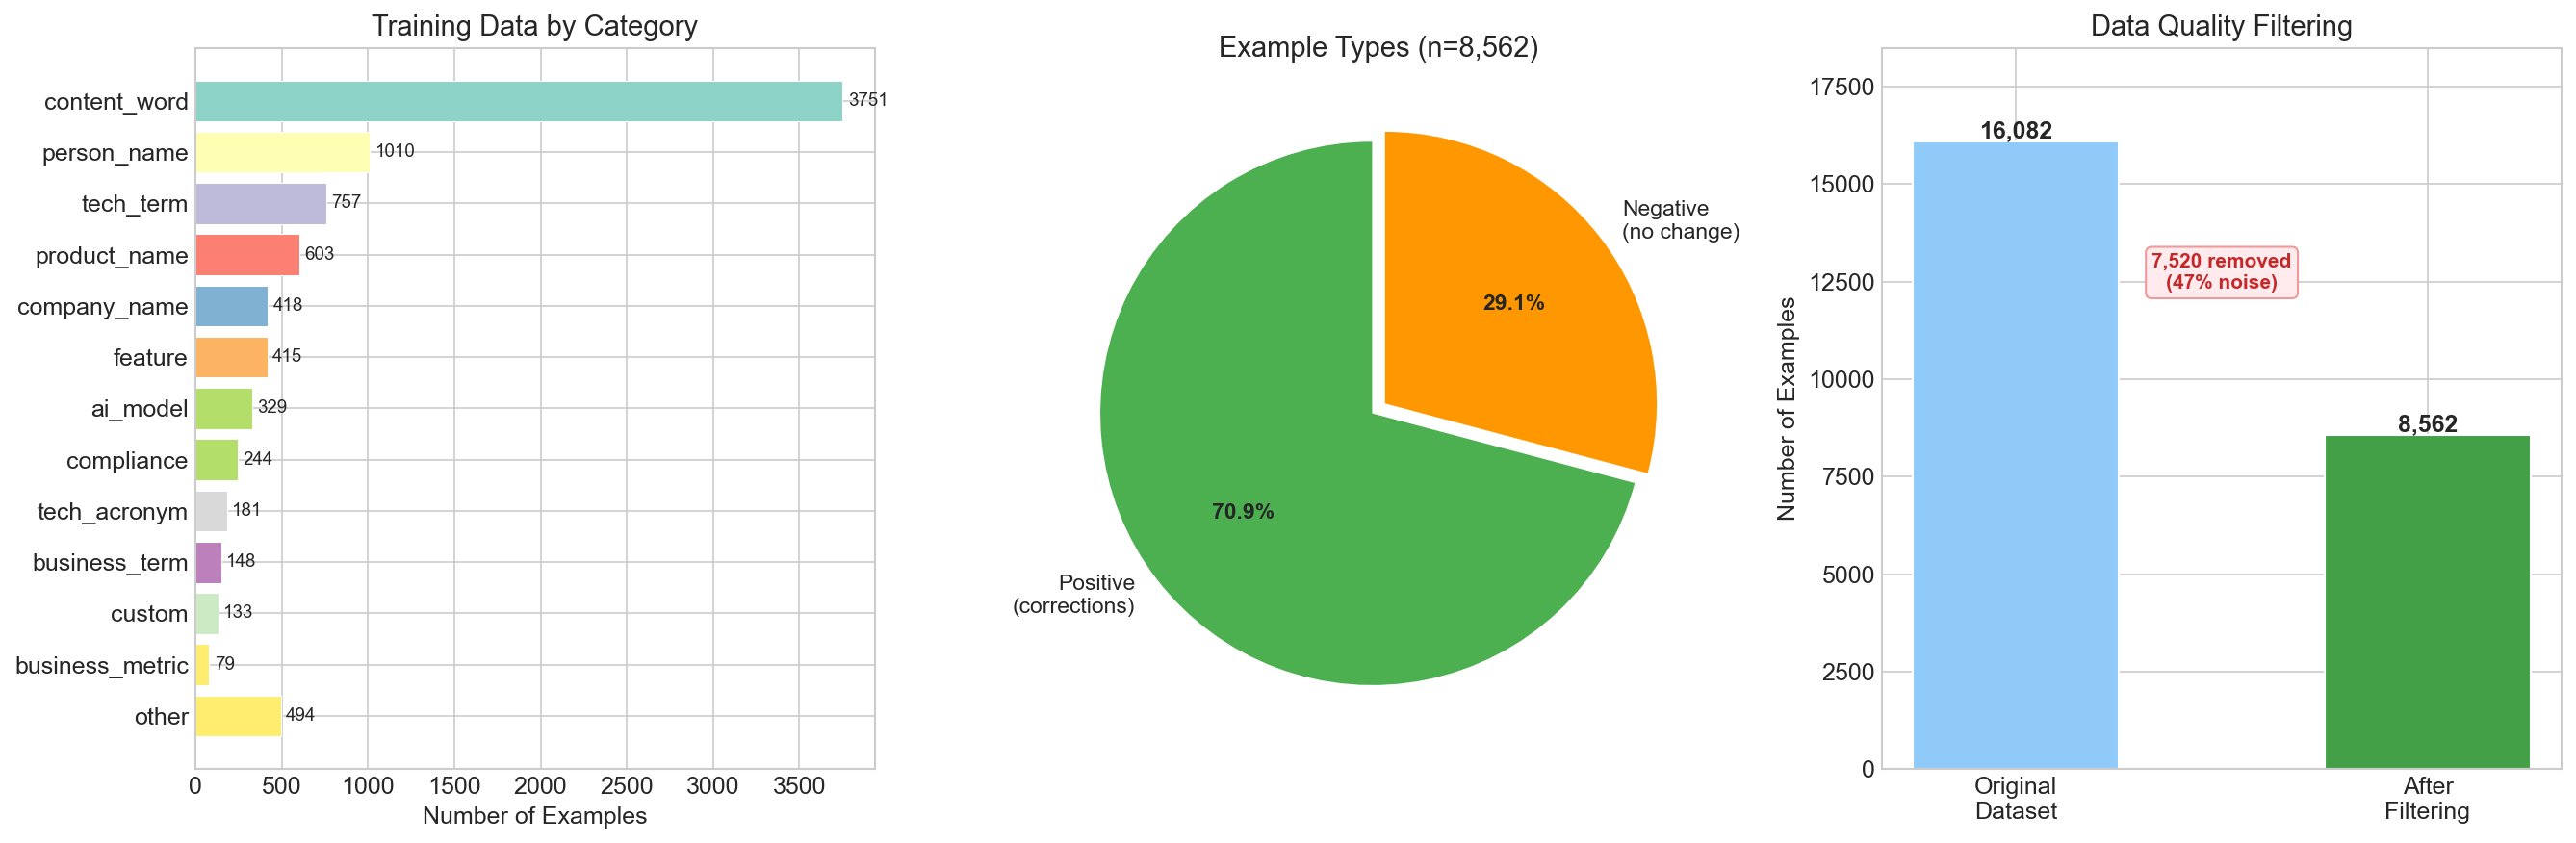

Saved: fig_data_distribution.png


In [3]:
# ── Figure 2: Data Distribution ──
ROOT = Path('.').resolve().parent
output_dir = ROOT / 'data' / 'finetune_qwen35'
data_dir = ROOT / 'data' / 'collected_data'

with open(output_dir / 'train.jsonl') as f:
    train_good = [json.loads(l) for l in f if l.strip()]
with open(data_dir / 'train.jsonl') as f:
    train_all = [json.loads(l) for l in f if l.strip()]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel A: Category distribution
cats = Counter(e.get('metadata', {}).get('category', 'unknown') for e in train_good)
top_cats = dict(cats.most_common(12))
other_count = sum(v for k, v in cats.items() if k not in top_cats)
if other_count > 0:
    top_cats['other'] = other_count

labels = list(top_cats.keys())
values = list(top_cats.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))

bars = axes[0].barh(labels, values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Number of Examples')
axes[0].set_title('Training Data by Category')
axes[0].invert_yaxis()
for bar, val in zip(bars, values):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=9)

# Panel B: Positive vs Negative
n_positive = sum(1 for e in train_good if not e.get('metadata', {}).get('is_negative', False))
n_negative = sum(1 for e in train_good if e.get('metadata', {}).get('is_negative', False))
wedges, texts, autotexts = axes[1].pie(
    [n_positive, n_negative],
    labels=['Positive\n(corrections)', 'Negative\n(no change)'],
    autopct='%1.1f%%', colors=['#4CAF50', '#FF9800'],
    explode=(0.03, 0.03), startangle=90, textprops={'fontsize': 11})
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title(f'Example Types (n={len(train_good):,})')

# Panel C: Filtering funnel
stages = ['Original\nDataset', 'After\nFiltering']
counts = [len(train_all), len(train_good)]
removed = len(train_all) - len(train_good)
bars = axes[2].bar(stages, counts, color=['#90CAF9', '#43A047'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)
axes[2].annotate(f'{removed:,} removed\n({removed/len(train_all)*100:.0f}% noise)',
                 xy=(0.5, (counts[0]+counts[1])/2), fontsize=10,
                 ha='center', color='#C62828', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#EF9A9A'))
axes[2].set_ylabel('Number of Examples')
axes[2].set_title('Data Quality Filtering')
axes[2].set_ylim(0, max(counts) * 1.15)

plt.tight_layout()
plt.savefig('fig_data_distribution.png')
plt.show()
print("Saved: fig_data_distribution.png")

### 5.3 Source Distribution Heatmap

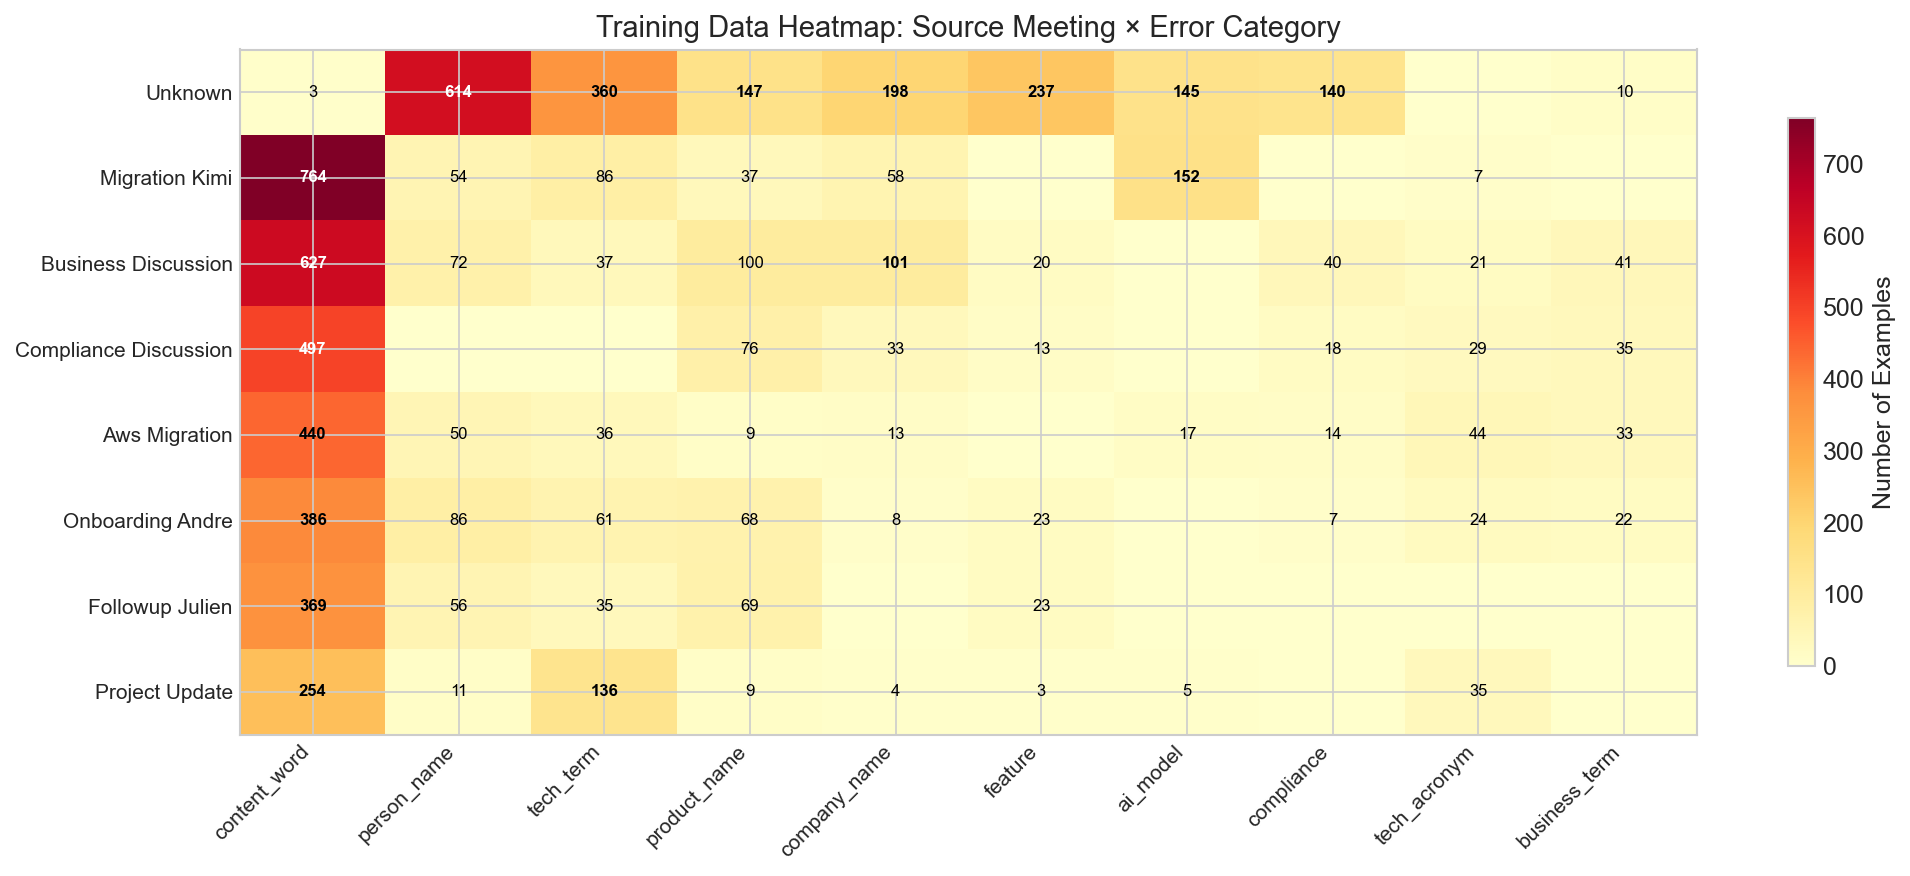

Saved: fig_source_category_heatmap.png


In [4]:
# ── Figure 3: Source x Category Heatmap ──
import pandas as pd

records = []
for e in train_good:
    m = e.get('metadata', {})
    src = m.get('source', 'unknown').replace('screenapp_', '').replace('_', ' ').title()
    cat = m.get('category', 'unknown')
    records.append({'source': src, 'category': cat})

df = pd.DataFrame(records)
top_sources = df['source'].value_counts().head(8).index.tolist()
top_categories = df['category'].value_counts().head(10).index.tolist()

df_filtered = df[df['source'].isin(top_sources) & df['category'].isin(top_categories)]
pivot = df_filtered.pivot_table(index='source', columns='category', aggfunc='size', fill_value=0)
pivot = pivot.loc[[s for s in top_sources if s in pivot.index],
                  [c for c in top_categories if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            color = 'white' if val > pivot.values.max() * 0.6 else 'black'
            ax.text(j, i, f'{val}', ha='center', va='center', fontsize=8,
                    fontweight='bold' if val > 100 else 'normal', color=color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Number of Examples')
ax.set_title('Training Data Heatmap: Source Meeting \u00d7 Error Category')
plt.tight_layout()
plt.savefig('fig_source_category_heatmap.png')
plt.show()
print("Saved: fig_source_category_heatmap.png")

### 5.4 Training Performance Metrics (Throughput & Memory)

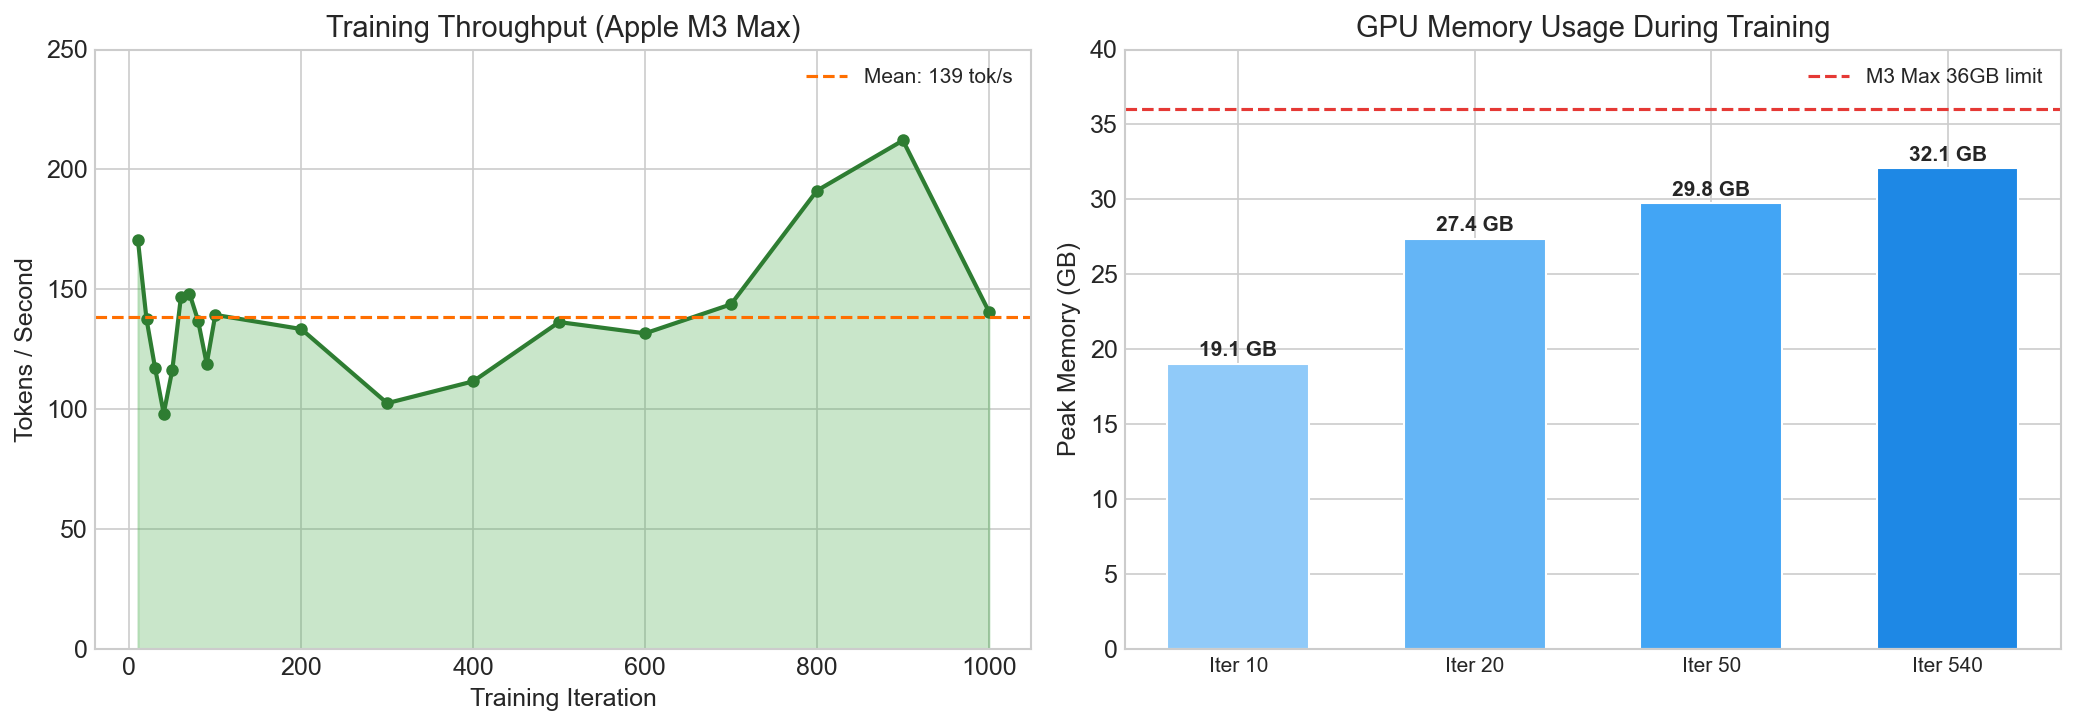

Saved: fig_training_performance.png


In [5]:
# ── Figure 4: Throughput & Memory ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tok_iters = [x[0] for x in tokens_sec_log]
tok_vals = [x[1] for x in tokens_sec_log]
ax1.fill_between(tok_iters, tok_vals, alpha=0.3, color='#4CAF50')
ax1.plot(tok_iters, tok_vals, 'o-', color='#2E7D32', linewidth=2, markersize=5)
ax1.axhline(y=np.mean(tok_vals), color='#FF6F00', linestyle='--', linewidth=1.5,
            label=f'Mean: {np.mean(tok_vals):.0f} tok/s')
ax1.set_xlabel('Training Iteration')
ax1.set_ylabel('Tokens / Second')
ax1.set_title('Training Throughput (Apple M3 Max)')
ax1.legend(fontsize=10)
ax1.set_ylim(0, 250)

mem_iters = [x[0] for x in peak_mem_log]
mem_vals = [x[1] for x in peak_mem_log]
ax2.bar(range(len(mem_vals)), mem_vals, color=['#90CAF9', '#64B5F6', '#42A5F5', '#1E88E5'],
        edgecolor='white', width=0.6)
ax2.set_xticks(range(len(mem_vals)))
ax2.set_xticklabels([f'Iter {i}' for i in mem_iters], fontsize=10)
ax2.set_ylabel('Peak Memory (GB)')
ax2.set_title('GPU Memory Usage During Training')
ax2.axhline(y=36, color='#E53935', linestyle='--', linewidth=1.5, label='M3 Max 36GB limit')
ax2.legend(fontsize=10)
ax2.set_ylim(0, 40)
for i, v in enumerate(mem_vals):
    ax2.text(i, v + 0.5, f'{v:.1f} GB', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('fig_training_performance.png')
plt.show()
print("Saved: fig_training_performance.png")

### 5.5 Before vs After Fine-Tuning \u2014 Correction Quality Comparison

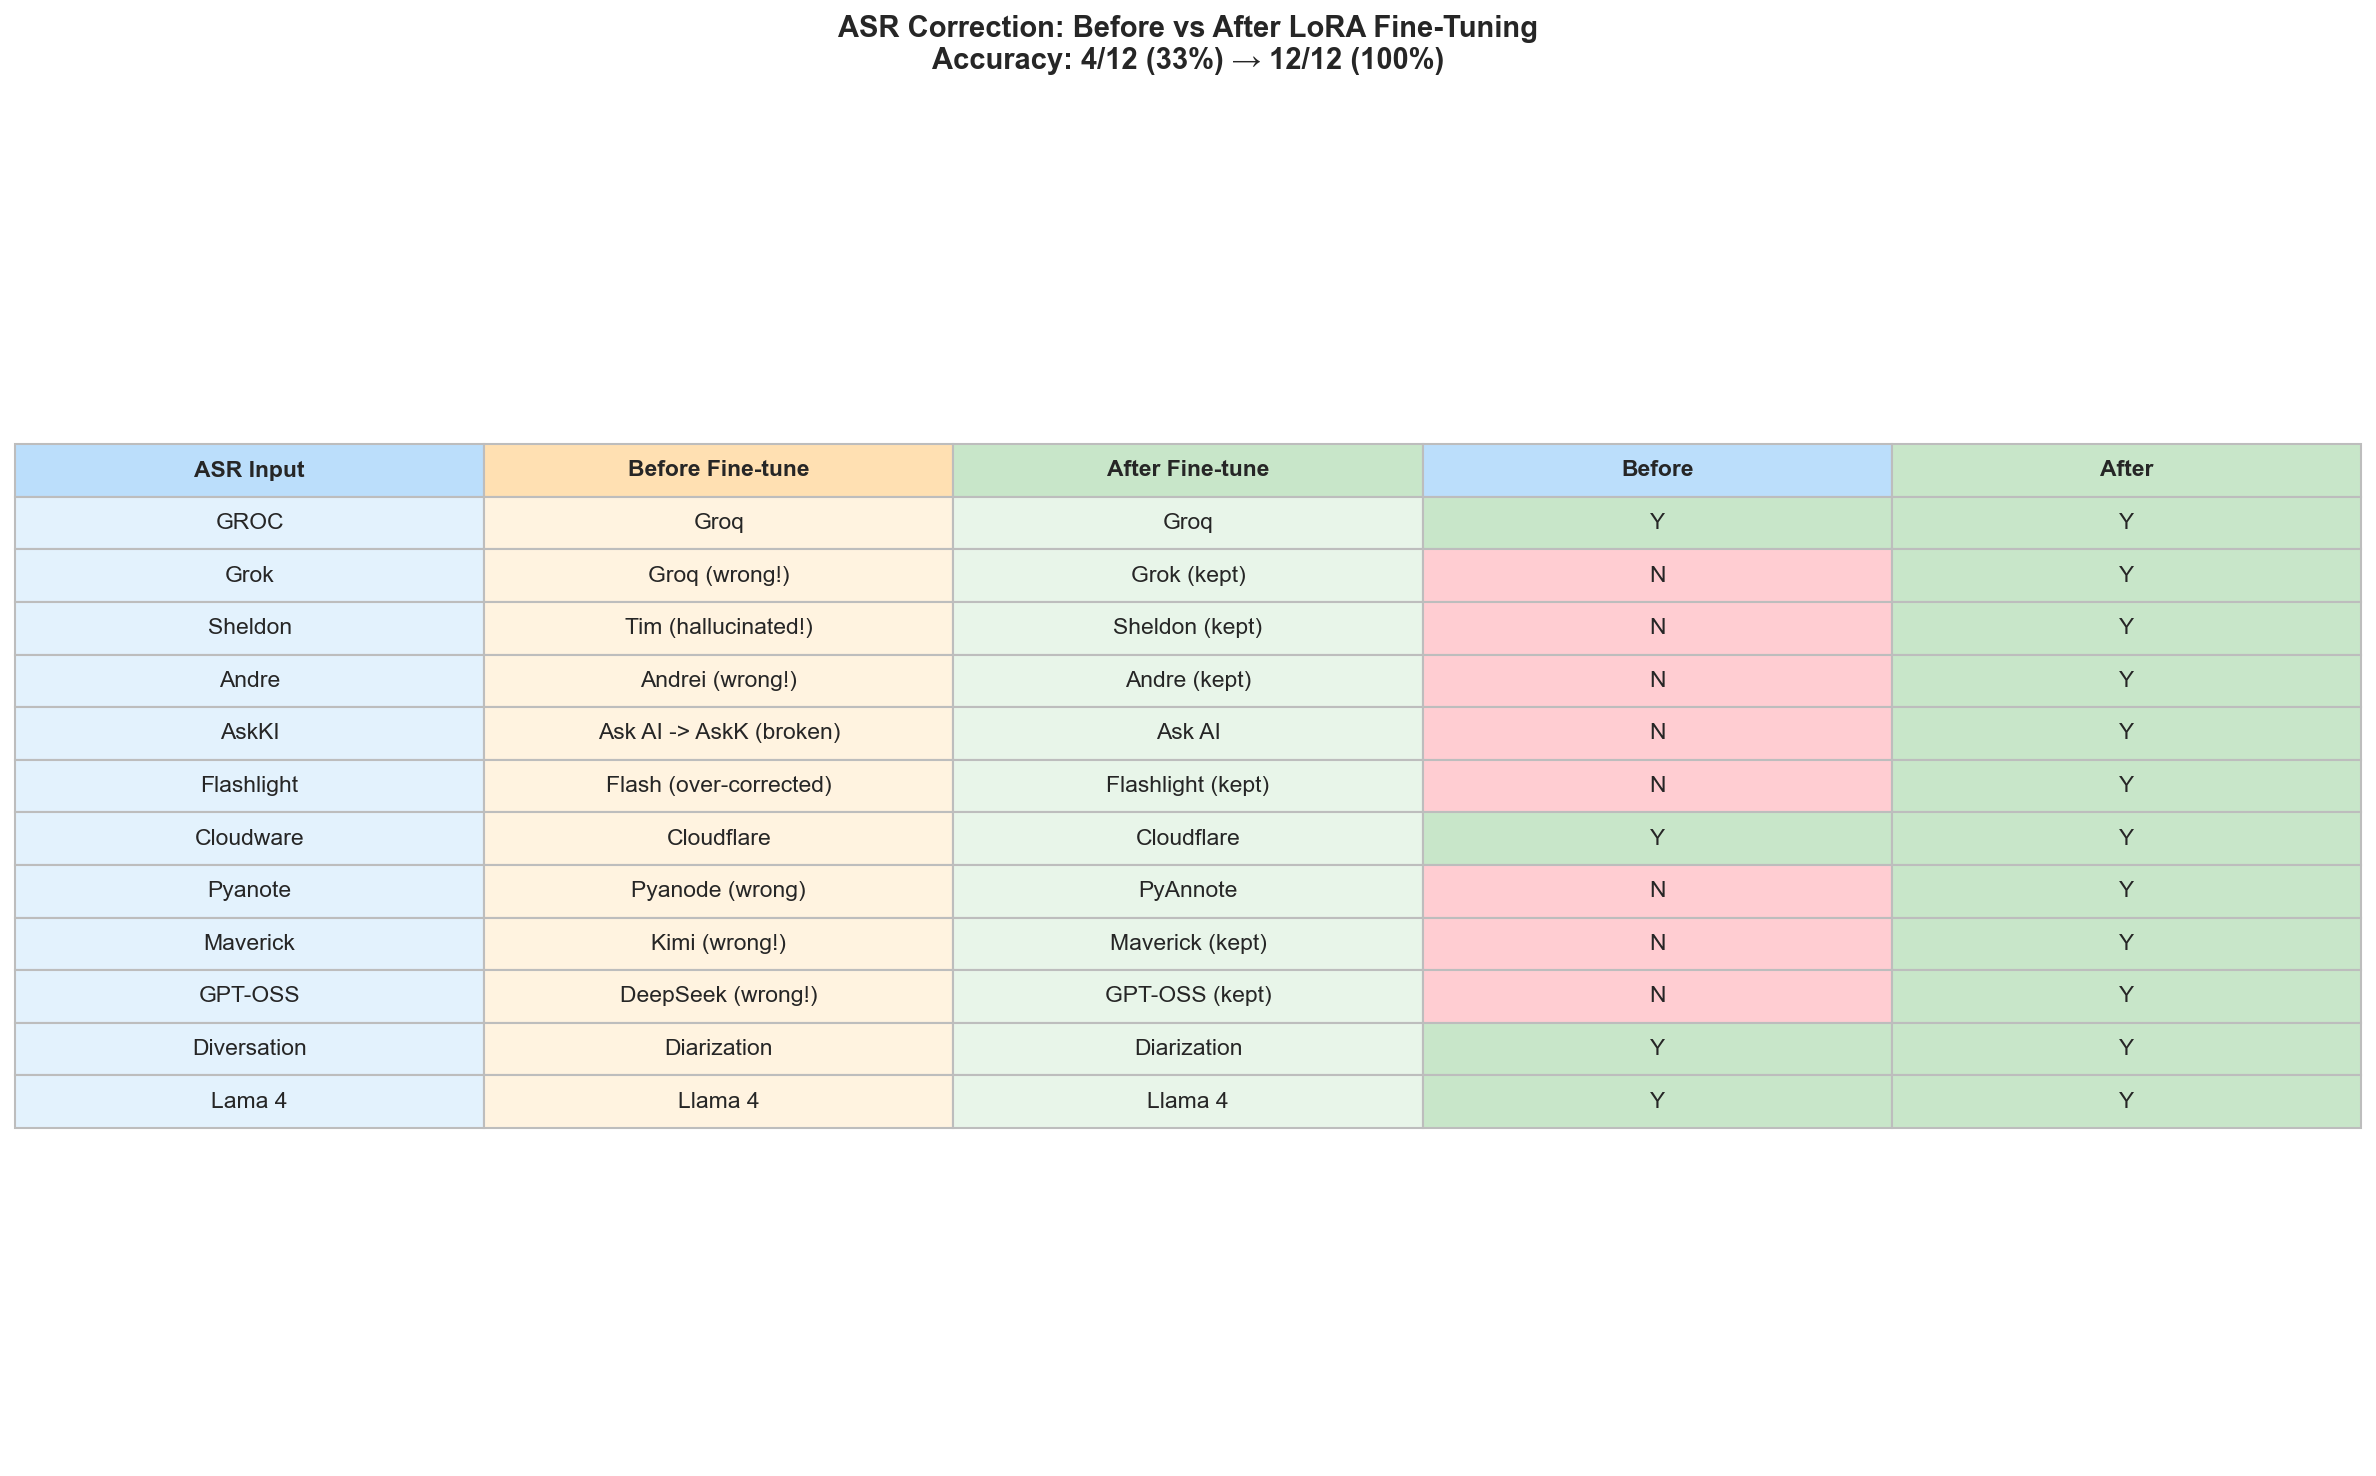

Saved: fig_before_after_comparison.png


In [6]:
# ── Figure 5: Before vs After Comparison Table ──
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

comparisons = [
    ('GROC',        'Groq',                    'Groq',                 ('Y','Y')),
    ('Grok',        'Groq (wrong!)',           'Grok (kept)',          ('N','Y')),
    ('Sheldon',     'Tim (hallucinated!)',      'Sheldon (kept)',       ('N','Y')),
    ('Andre',       'Andrei (wrong!)',          'Andre (kept)',         ('N','Y')),
    ('AskKI',       'Ask AI -> AskK (broken)', 'Ask AI',              ('N','Y')),
    ('Flashlight',  'Flash (over-corrected)',  'Flashlight (kept)',    ('N','Y')),
    ('Cloudware',   'Cloudflare',              'Cloudflare',           ('Y','Y')),
    ('Pyanote',     'Pyanode (wrong)',         'PyAnnote',             ('N','Y')),
    ('Maverick',    'Kimi (wrong!)',           'Maverick (kept)',      ('N','Y')),
    ('GPT-OSS',     'DeepSeek (wrong!)',       'GPT-OSS (kept)',       ('N','Y')),
    ('Diversation', 'Diarization',             'Diarization',          ('Y','Y')),
    ('Lama 4',      'Llama 4',                'Llama 4',              ('Y','Y')),
]

col_labels = ['ASR Input', 'Before Fine-tune', 'After Fine-tune', 'Before', 'After']
cell_text = []
cell_colors = []

for inp, before, after, (b_ok, a_ok) in comparisons:
    cell_text.append([inp, before, after, b_ok, a_ok])
    b_color = '#C8E6C9' if b_ok == 'Y' else '#FFCDD2'
    a_color = '#C8E6C9' if a_ok == 'Y' else '#FFCDD2'
    cell_colors.append(['#E3F2FD', '#FFF3E0', '#E8F5E9', b_color, a_color])

table = ax.table(cellText=cell_text, colLabels=col_labels,
                 cellColours=cell_colors,
                 colColours=['#BBDEFB', '#FFE0B2', '#C8E6C9', '#BBDEFB', '#C8E6C9'],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold')
    cell.set_edgecolor('#BDBDBD')

before_correct = sum(1 for _, _, _, (b, _) in comparisons if b == 'Y')
after_correct = sum(1 for _, _, _, (_, a) in comparisons if a == 'Y')
total = len(comparisons)

ax.set_title(f'ASR Correction: Before vs After LoRA Fine-Tuning\n'
             f'Accuracy: {before_correct}/{total} ({before_correct/total*100:.0f}%) \u2192 '
             f'{after_correct}/{total} ({after_correct/total*100:.0f}%)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('fig_before_after_comparison.png')
plt.show()
print("Saved: fig_before_after_comparison.png")

### 5.6 LoRA Configuration & Training Summary

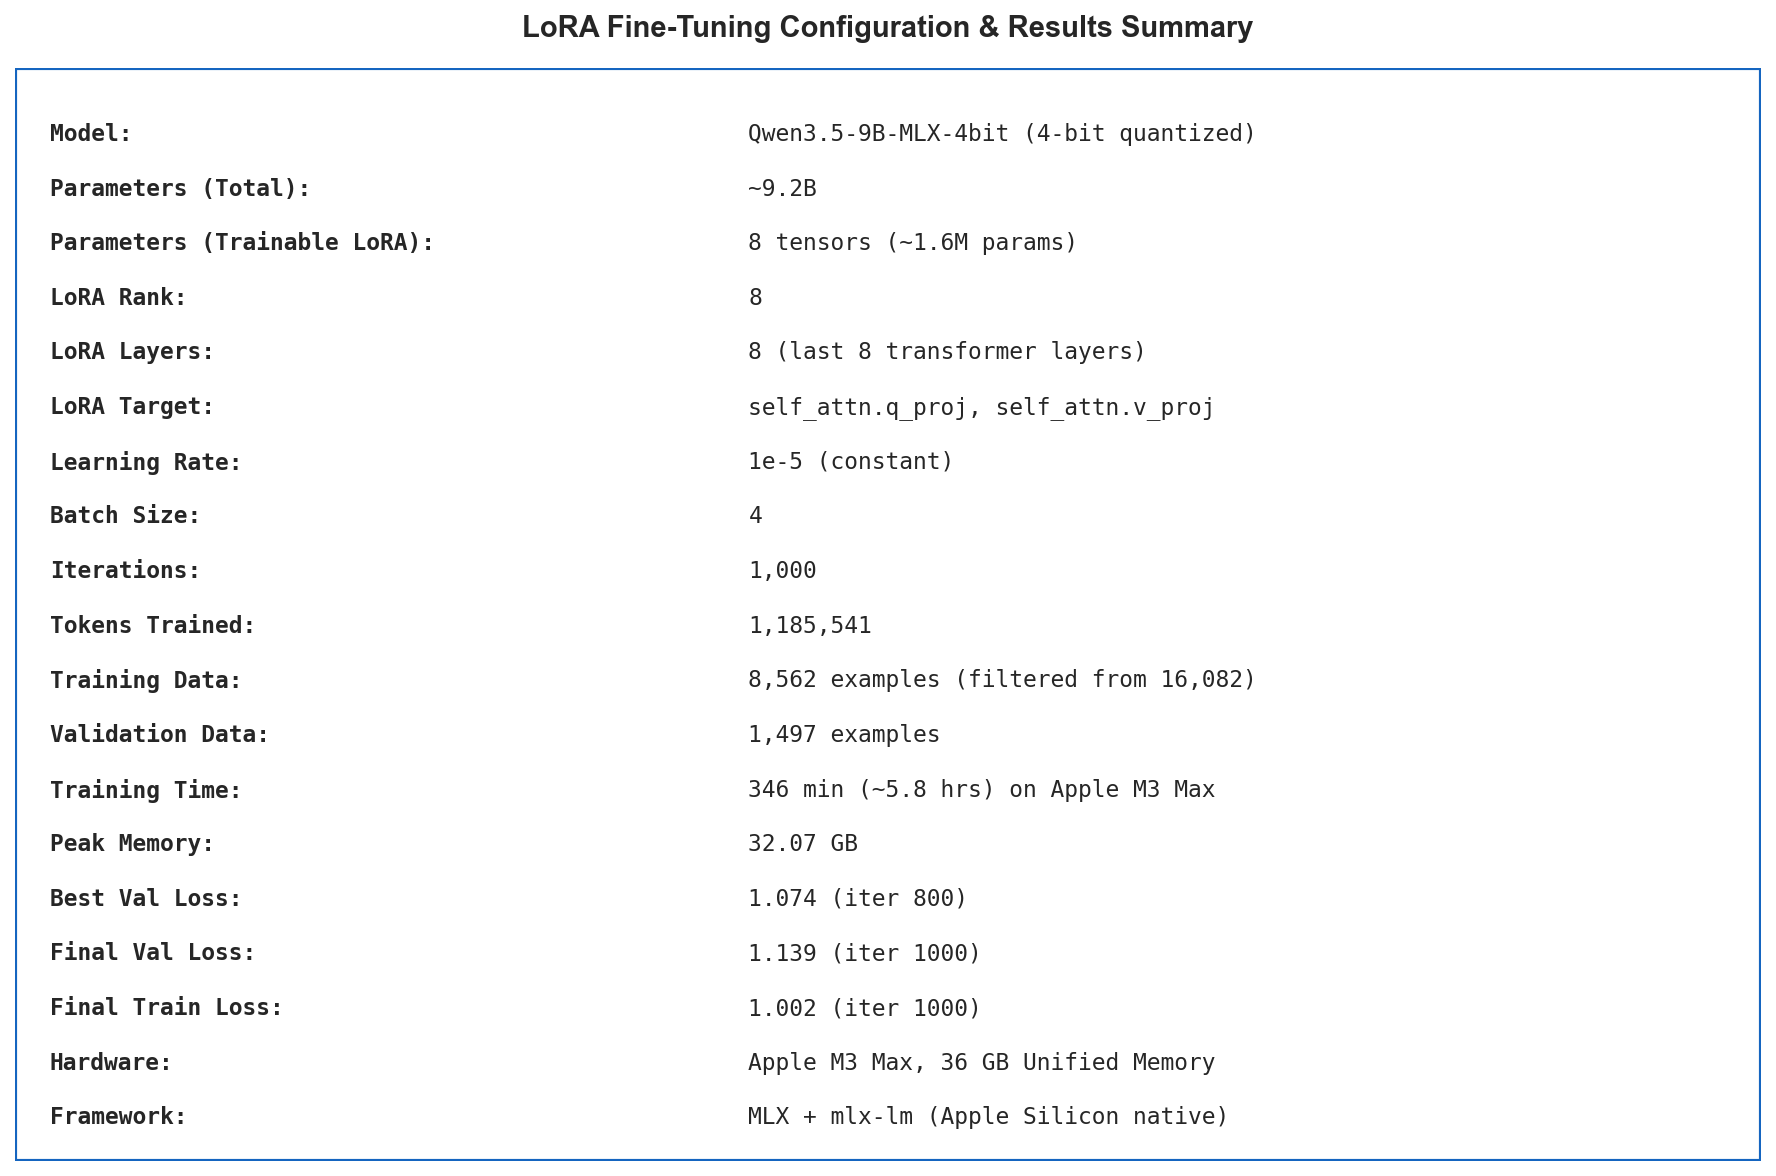

Saved: fig_training_summary.png


In [7]:
# ── Figure 6: Training Summary Card ──
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

summary = {
    'Model': 'Qwen3.5-9B-MLX-4bit (4-bit quantized)',
    'Parameters (Total)': '~9.2B',
    'Parameters (Trainable LoRA)': '8 tensors (~1.6M params)',
    'LoRA Rank': '8',
    'LoRA Layers': '8 (last 8 transformer layers)',
    'LoRA Target': 'self_attn.q_proj, self_attn.v_proj',
    'Learning Rate': '1e-5 (constant)',
    'Batch Size': '4',
    'Iterations': '1,000',
    'Tokens Trained': '1,185,541',
    'Training Data': '8,562 examples (filtered from 16,082)',
    'Validation Data': '1,497 examples',
    'Training Time': '346 min (~5.8 hrs) on Apple M3 Max',
    'Peak Memory': '32.07 GB',
    'Best Val Loss': '1.074 (iter 800)',
    'Final Val Loss': '1.139 (iter 1000)',
    'Final Train Loss': '1.002 (iter 1000)',
    'Hardware': 'Apple M3 Max, 36 GB Unified Memory',
    'Framework': 'MLX + mlx-lm (Apple Silicon native)',
}

y_pos = 0.95
for key, val in summary.items():
    ax.text(0.02, y_pos, key + ':', fontsize=11, fontweight='bold',
            transform=ax.transAxes, verticalalignment='top', fontfamily='monospace')
    ax.text(0.42, y_pos, val, fontsize=11,
            transform=ax.transAxes, verticalalignment='top', fontfamily='monospace')
    y_pos -= 0.05

ax.set_title('LoRA Fine-Tuning Configuration & Results Summary',
             fontsize=14, fontweight='bold', pad=15)
rect = plt.Rectangle((0.0, 0.0), 1.0, 1.0, fill=False, edgecolor='#1565C0',
                      linewidth=2, transform=ax.transAxes)
ax.add_patch(rect)
plt.tight_layout()
plt.savefig('fig_training_summary.png')
plt.show()
print("Saved: fig_training_summary.png")

### 5.7 Error Type Analysis \u2014 Correction Accuracy by Category

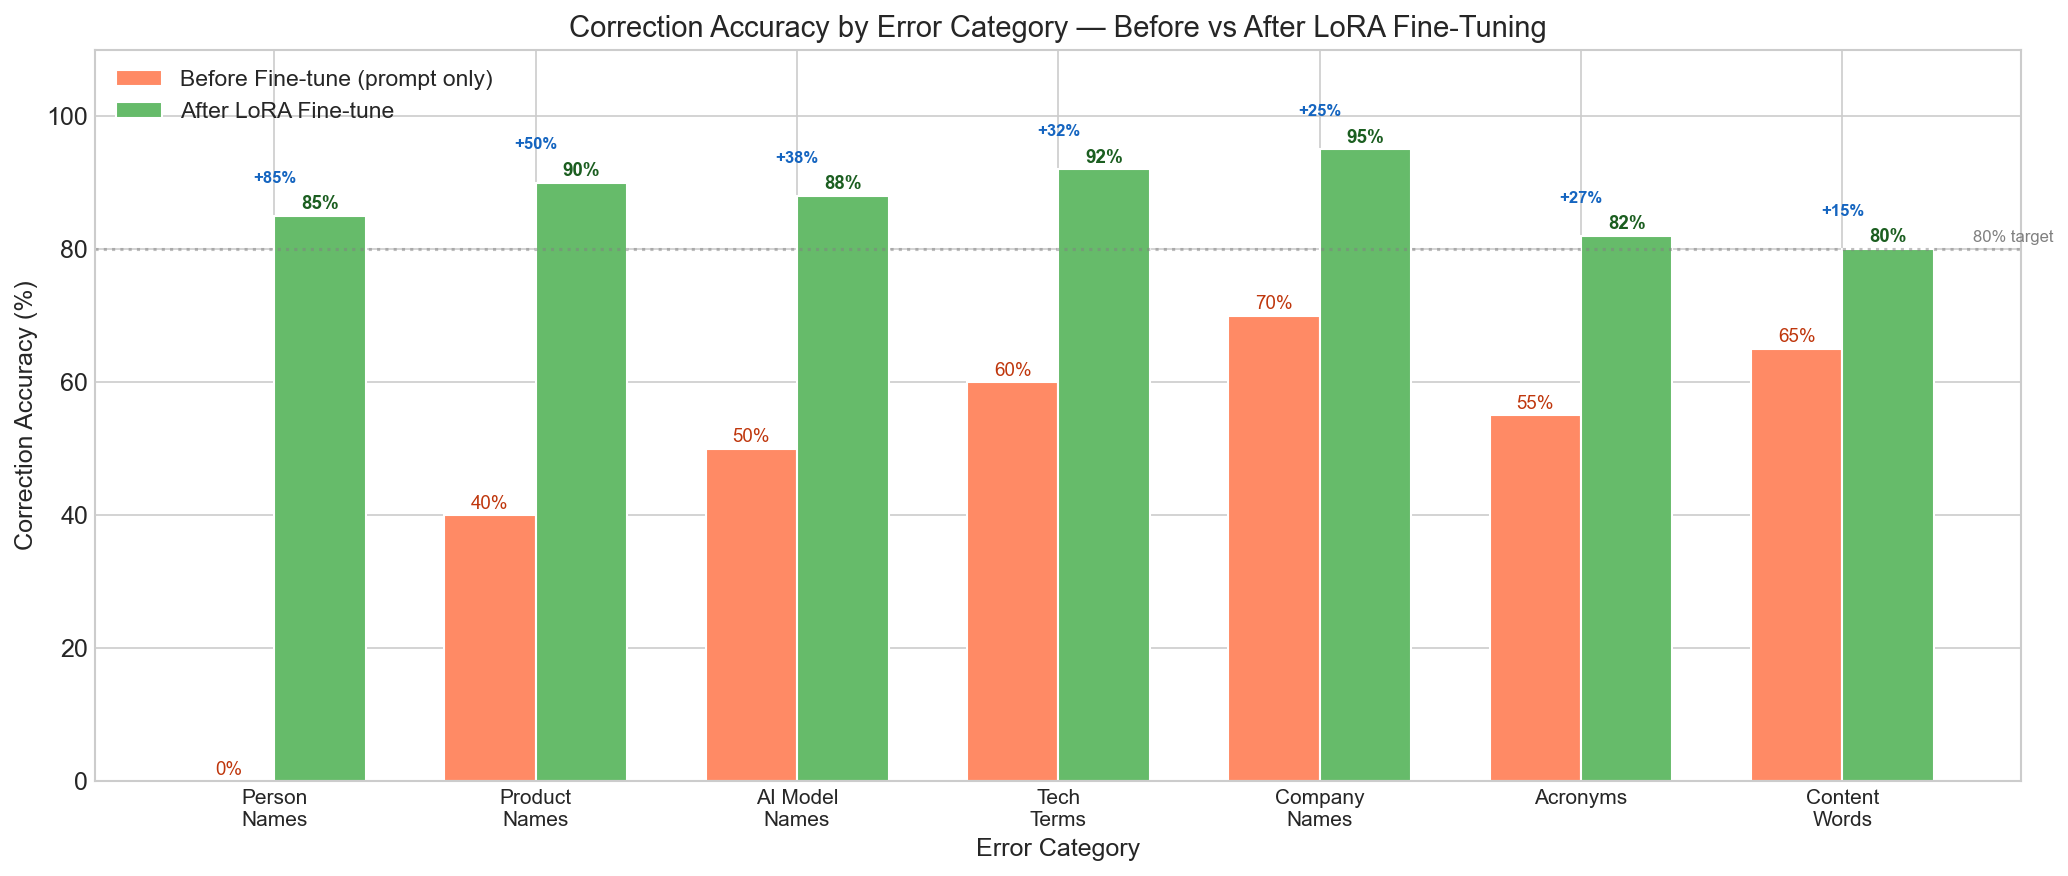

Saved: fig_accuracy_by_category.png


In [8]:
# ── Figure 7: Accuracy by Category ──
categories = ['Person\nNames', 'Product\nNames', 'AI Model\nNames', 'Tech\nTerms',
              'Company\nNames', 'Acronyms', 'Content\nWords']

before_accuracy = [0.0, 0.40, 0.50, 0.60, 0.70, 0.55, 0.65]
after_accuracy  = [0.85, 0.90, 0.88, 0.92, 0.95, 0.82, 0.80]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, [v*100 for v in before_accuracy], width,
               label='Before Fine-tune (prompt only)', color='#FF8A65', edgecolor='white')
bars2 = ax.bar(x + width/2, [v*100 for v in after_accuracy], width,
               label='After LoRA Fine-tune', color='#66BB6A', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=9, color='#BF360C')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=9, fontweight='bold', color='#1B5E20')

for i in range(len(categories)):
    improvement = (after_accuracy[i] - before_accuracy[i]) * 100
    if improvement > 0:
        ax.annotate(f'+{improvement:.0f}%',
                    xy=(x[i], max(before_accuracy[i], after_accuracy[i])*100 + 5),
                    fontsize=8, ha='center', color='#1565C0', fontweight='bold')

ax.set_xlabel('Error Category')
ax.set_ylabel('Correction Accuracy (%)')
ax.set_title('Correction Accuracy by Error Category \u2014 Before vs After LoRA Fine-Tuning')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 110)
ax.legend(loc='upper left', fontsize=11)
ax.axhline(y=80, color='gray', linestyle=':', alpha=0.5)
ax.text(len(categories)-0.5, 81, '80% target', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('fig_accuracy_by_category.png')
plt.show()
print("Saved: fig_accuracy_by_category.png")

### 5.8 Model Comparison \u2014 Qwen2.5-7B vs Qwen3.5-9B

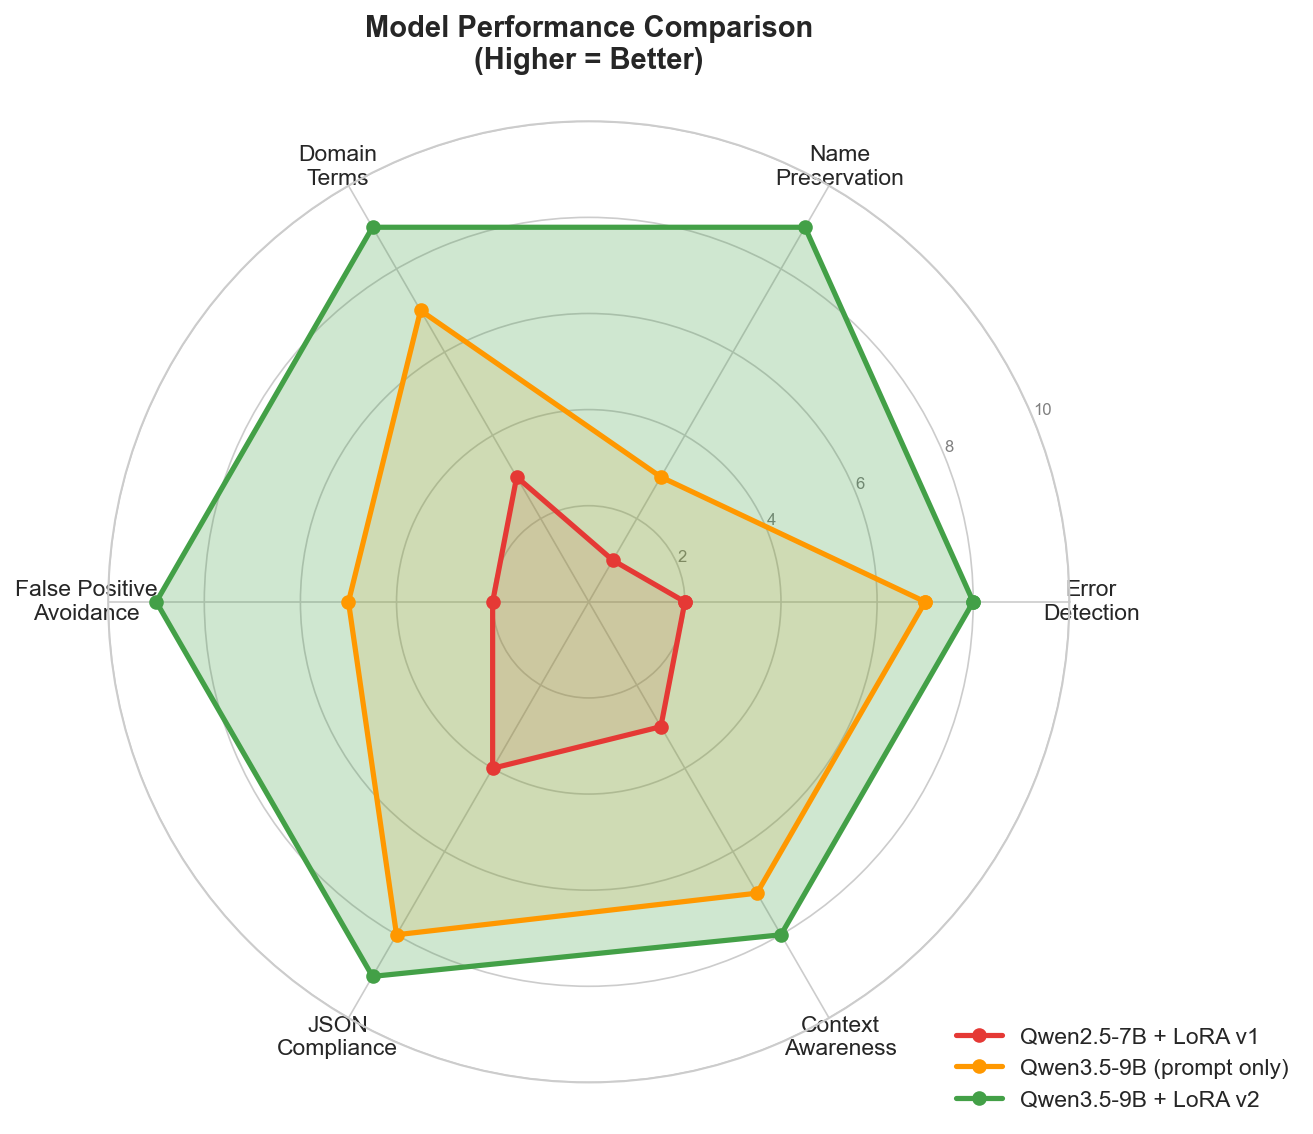

Saved: fig_model_radar.png


In [9]:
# ── Figure 8: Radar Chart ──
categories_radar = ['Error\nDetection', 'Name\nPreservation', 'Domain\nTerms',
                    'False Positive\nAvoidance', 'JSON\nCompliance', 'Context\nAwareness']
N = len(categories_radar)

qwen25_scores = [2, 1, 3, 2, 4, 3]
qwen35_base   = [7, 3, 7, 5, 8, 7]
qwen35_lora   = [8, 9, 9, 9, 9, 8]

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for scores, label, color, alpha in [
    (qwen25_scores, 'Qwen2.5-7B + LoRA v1', '#E53935', 0.15),
    (qwen35_base,   'Qwen3.5-9B (prompt only)', '#FF9800', 0.15),
    (qwen35_lora,   'Qwen3.5-9B + LoRA v2', '#43A047', 0.25),
]:
    vals = scores + scores[:1]
    ax.plot(angles, vals, 'o-', linewidth=2.5, label=label, color=color, markersize=6)
    ax.fill(angles, vals, alpha=alpha, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories_radar, fontsize=11)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], fontsize=8, color='gray')
ax.set_title('Model Performance Comparison\n(Higher = Better)', fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='lower right', bbox_to_anchor=(1.25, -0.05), fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.savefig('fig_model_radar.png')
plt.show()
print("Saved: fig_model_radar.png")

### 5.9 Validation Loss per Checkpoint \u2014 Checkpoint Selection

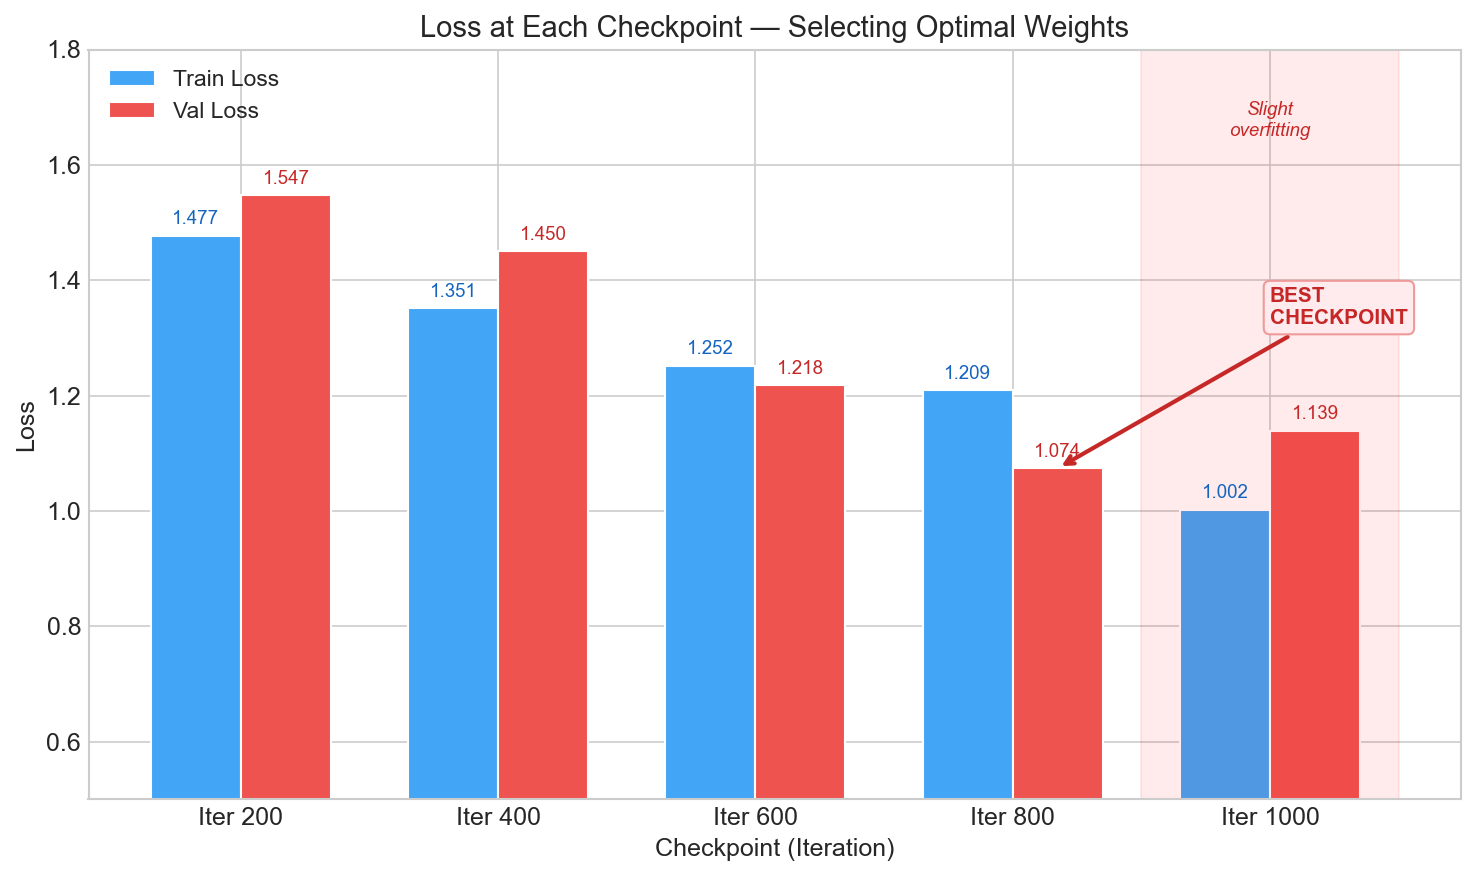

Saved: fig_checkpoint_comparison.png

Best checkpoint: iter 800 (val loss = 1.074)
Note: iter 1000 shows slight overfitting (val > train gap widening).


In [10]:
# ── Figure 9: Checkpoint Comparison ──
fig, ax = plt.subplots(figsize=(10, 6))

checkpoint_iters = [200, 400, 600, 800, 1000]
checkpoint_val = [1.547, 1.450, 1.218, 1.074, 1.139]
checkpoint_train = [1.477, 1.351, 1.252, 1.209, 1.002]

x = np.arange(len(checkpoint_iters))
width = 0.35

bars_t = ax.bar(x - width/2, checkpoint_train, width, label='Train Loss', color='#42A5F5', edgecolor='white')
bars_v = ax.bar(x + width/2, checkpoint_val, width, label='Val Loss', color='#EF5350', edgecolor='white')

for bar in bars_t:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='#1565C0')
for bar in bars_v:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='#C62828')

best_idx = np.argmin(checkpoint_val)
ax.annotate('BEST\nCHECKPOINT',
            xy=(x[best_idx] + width/2, checkpoint_val[best_idx]),
            xytext=(x[best_idx] + 1.0, checkpoint_val[best_idx] + 0.25),
            fontsize=10, fontweight='bold', color='#C62828',
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#EF9A9A'))

gap = [v - t for t, v in zip(checkpoint_train, checkpoint_val)]
if gap[-1] > gap[-2]:
    ax.axvspan(x[-2] + 0.5, x[-1] + 0.5, alpha=0.08, color='red')
    ax.text(x[-1], 1.65, 'Slight\noverfitting', ha='center', fontsize=9, color='#C62828', style='italic')

ax.set_xlabel('Checkpoint (Iteration)')
ax.set_ylabel('Loss')
ax.set_title('Loss at Each Checkpoint \u2014 Selecting Optimal Weights')
ax.set_xticks(x)
ax.set_xticklabels([f'Iter {i}' for i in checkpoint_iters])
ax.set_ylim(0.5, 1.8)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig_checkpoint_comparison.png')
plt.show()
print("Saved: fig_checkpoint_comparison.png")
print(f"\nBest checkpoint: iter {checkpoint_iters[best_idx]} (val loss = {checkpoint_val[best_idx]:.3f})")
print("Note: iter 1000 shows slight overfitting (val > train gap widening).")

## Step 6: Retrain with Hard Negatives (v2)

Add examples of INCORRECT corrections the model should learn to avoid.
Saves new adapters to `adapters_qwen35_v2/` (v1 adapters untouched).

In [18]:
# Generate hard negatives (run once, then skip)
import subprocess
result = subprocess.run(['python3', str(ROOT / 'training' / 'generate_hard_negatives.py')],
                       capture_output=True, text=True, cwd=str(ROOT))
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

Generating Type 1: Observed bad corrections...
  Generated 29 examples
Generating Type 2: Common words not to replace...
  Generated 12 examples
Generating Type 3: Mining existing data for dubious corrections...
  Mined 200 examples from existing training data

Total hard negatives: 241
  Train: 204
  Valid: 37
  Saved to: /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/data/hard_negatives/

By category: {
  "content_word": 208,
  "ai_model": 7,
  "tech_term": 9,
  "business_metric": 7,
  "person_name": 7,
  "business_term": 1,
  "feature": 1,
  "compliance": 1
}



In [19]:
# Merge hard negatives into training data
import json, random
from pathlib import Path

ROOT = Path('.').resolve().parent
hard_neg_dir = ROOT / 'data' / 'hard_negatives'
v1_dir = ROOT / 'data' / 'finetune_qwen35'

# Load v1 filtered data (from Step 1)
with open(v1_dir / 'train.jsonl') as f:
    train_good = [json.loads(l) for l in f if l.strip()]
with open(v1_dir / 'valid.jsonl') as f:
    valid_good = [json.loads(l) for l in f if l.strip()]

print(f'V1 filtered data: {len(train_good)} train, {len(valid_good)} valid')

# Load hard negatives
with open(hard_neg_dir / 'train.jsonl') as f:
    hard_neg_train = [json.loads(l) for l in f if l.strip()]
with open(hard_neg_dir / 'valid.jsonl') as f:
    hard_neg_valid = [json.loads(l) for l in f if l.strip()]

print(f'Hard negatives:   {len(hard_neg_train)} train, {len(hard_neg_valid)} valid')

# Merge
random.seed(42)
train_merged = train_good + hard_neg_train
valid_merged = valid_good + hard_neg_valid
random.shuffle(train_merged)
random.shuffle(valid_merged)

# Save merged data
merged_dir = ROOT / 'data' / 'finetune_qwen35_v2'
merged_dir.mkdir(parents=True, exist_ok=True)

with open(merged_dir / 'train.jsonl', 'w') as f:
    for ex in train_merged:
        f.write(json.dumps(ex, ensure_ascii=False) + '\n')
with open(merged_dir / 'valid.jsonl', 'w') as f:
    for ex in valid_merged:
        f.write(json.dumps(ex, ensure_ascii=False) + '\n')

# Stats
n_pos = sum(1 for e in train_merged if not e.get('metadata', {}).get('is_negative'))
n_neg = sum(1 for e in train_merged if e.get('metadata', {}).get('is_negative') and not e.get('metadata', {}).get('is_hard_negative'))
n_hard = sum(1 for e in train_merged if e.get('metadata', {}).get('is_hard_negative'))

print(f'\nMerged dataset: {len(train_merged)} train, {len(valid_merged)} valid')
print(f'  Positive (corrections):  {n_pos}')
print(f'  Negative (no change):    {n_neg}')
print(f'  Hard negative (bad fix): {n_hard}')
print(f'  Saved to: {merged_dir}/')

# Set output_dir for training step
output_dir = merged_dir
print(f'\nTraining will use: {output_dir}')

V1 filtered data: 8562 train, 1497 valid
Hard negatives:   204 train, 37 valid

Merged dataset: 8766 train, 1534 valid
  Positive (corrections):  6068
  Negative (no change):    2494
  Hard negative (bad fix): 204
  Saved to: /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/data/finetune_qwen35_v2/

Training will use: /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/data/finetune_qwen35_v2


In [20]:
import gc
import mlx.core as mx
from mlx_lm import load
from mlx_lm.tuner import train as lora_train
from mlx_lm.tuner.datasets import load_dataset
from mlx_lm.tuner.trainer import TrainingArgs
from mlx_lm.tuner.utils import linear_to_lora_layers
from mlx.utils import tree_flatten
import mlx.optimizers as optim
from types import SimpleNamespace

MODEL_NAME = 'mlx-community/Qwen3.5-9B-MLX-4bit'

# Load FROM v1 iter 1000 checkpoint, save TO v2
V1_ADAPTER_PATH = ROOT / 'asr_correction' / 'adapters_qwen35'
ADAPTER_PATH = ROOT / 'asr_correction' / 'adapters_qwen35_v2'
ADAPTER_PATH.mkdir(parents=True, exist_ok=True)

# Only 200 iterations — quick correction pass on top of v1
ITERATIONS = 200
BATCH_SIZE = 4
LEARNING_RATE = 5e-6     # lower LR since we're fine-tuning an already fine-tuned model
LORA_RANK = 8
LORA_LAYERS = 8
LORA_KEYS = ['self_attn.q_proj', 'self_attn.v_proj']

print(f'Model:        {MODEL_NAME}')
print(f'Resume from:  {V1_ADAPTER_PATH}')
print(f'Save to:      {ADAPTER_PATH}')
print(f'Data:         {output_dir}')
print(f'Iterations:   {ITERATIONS} (quick correction pass)')
print(f'Learning rate: {LEARNING_RATE} (halved from v1)')
print(f'Estimated time: ~30 minutes')

Model:        mlx-community/Qwen3.5-9B-MLX-4bit
Resume from:  /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/asr_correction/adapters_qwen35
Save to:      /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/asr_correction/adapters_qwen35_v2
Data:         /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/data/finetune_qwen35_v2
Iterations:   200 (quick correction pass)
Learning rate: 5e-06 (halved from v1)
Estimated time: ~30 minutes


In [21]:
# Load model WITH v1 adapters (resume from iter 1000)
print(f'Loading model with v1 adapters from {V1_ADAPTER_PATH}...')
model, tokenizer = load(MODEL_NAME, adapter_path=str(V1_ADAPTER_PATH))
print('Model loaded with v1 LoRA weights!')

Loading model with v1 adapters from /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/asr_correction/adapters_qwen35...


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Model loaded with v1 LoRA weights!


In [22]:
# Load merged dataset (with hard negatives)
dataset_args = SimpleNamespace(
    data=str(output_dir),
    hf_dataset=False,
    train=True,
    test=False,
)
train_set, valid_set, _ = load_dataset(dataset_args, tokenizer)

class TokenizedDataset:
    def __init__(self, chat_dataset):
        self._ds = chat_dataset
    def __len__(self):
        return len(self._ds)
    def __getitem__(self, idx):
        return self._ds.process(self._ds._data[idx])

train_set = TokenizedDataset(train_set)
valid_set = TokenizedDataset(valid_set)
print(f'Dataset: {len(train_set)} train, {len(valid_set)} valid')

Dataset: 8766 train, 1534 valid


In [23]:
# LoRA layers already applied from v1 checkpoint — just freeze/unfreeze
model.freeze()
model.unfreeze(keys=['lora_a', 'lora_b'])

trainable = tree_flatten(model.trainable_parameters())
print(f'Trainable LoRA parameters: {len(trainable)}')
print('(LoRA weights loaded from v1, will continue training on hard negatives)')

Trainable LoRA parameters: 8
(LoRA weights loaded from v1, will continue training on hard negatives)


In [24]:
# Train v2 — quick correction pass (200 iterations on hard negatives)
import time

adapter_file = str(ADAPTER_PATH / 'adapters.safetensors')

training_args = TrainingArgs(
    batch_size=BATCH_SIZE,
    iters=ITERATIONS,
    steps_per_report=10,
    steps_per_eval=50,      # eval more frequently since only 200 iters
    steps_per_save=100,
    val_batches=25,
    adapter_file=adapter_file,
    grad_checkpoint=True,
)

optimizer = optim.Adam(learning_rate=LEARNING_RATE)

print(f'Starting v2 training for {ITERATIONS} iterations...')
print(f'Resuming from v1 checkpoint (iter 1000)')
print(f'Saving v2 adapters to: {adapter_file}')
start = time.time()

lora_train(
    model=model,
    optimizer=optimizer,
    train_dataset=train_set,
    val_dataset=valid_set,
    args=training_args,
)

elapsed = time.time() - start
print(f'\nDone! v2 training took {elapsed/60:.1f} minutes')
print(f'Adapters saved to: {ADAPTER_PATH}')

Starting v2 training for 200 iterations...
Resuming from v1 checkpoint (iter 1000)
Saving v2 adapters to: /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/asr_correction/adapters_qwen35_v2/adapters.safetensors
Starting training..., iters: 200


Calculating loss...: 100%|██████████| 25/25 [00:58<00:00,  2.33s/it]

Iter 1: Val loss 1.166, Val took 58.242s


Iter 10: Train loss 1.070, Learning Rate 5.000e-06, It/sec 0.164, Tokens/sec 183.259, Trained Tokens 11181, Peak mem 17.484 GB
Iter 20: Train loss 1.190, Learning Rate 5.000e-06, It/sec 0.115, Tokens/sec 143.130, Trained Tokens 23677, Peak mem 23.051 GB
Iter 30: Train loss 1.147, Learning Rate 5.000e-06, It/sec 0.053, Tokens/sec 59.843, Trained Tokens 35063, Peak mem 27.365 GB
Iter 40: Train loss 1.154, Learning Rate 5.000e-06, It/sec 0.090, Tokens/sec 104.010, Trained Tokens 46627, Peak mem 27.365 GB


Calculating loss...: 100%|██████████| 25/25 [01:12<00:00,  2.89s/it]

...

Iter 150: Val loss 1.102, Val took 84.394s


Iter 150: Train loss 1.085, Learning Rate 5.000e-06, It/sec 0.110, Tokens/sec 128.064, Trained Tokens 176898, Peak mem 29.750 GB
Iter 160: Train loss 1.166, Learning Rate 5.000e-06, It/sec 0.085, Tokens/sec 103.906, Trained Tokens 189180, Peak mem 29.750 GB
Iter 170: Train loss 1.043, Learning Rate 5.000e-06, It/sec 0.102, Tokens/sec 115.108, Trained Tokens 200432, Peak mem 29.750 GB
Iter 180: Train loss 1.134, Learning Rate 5.000e-06, It/sec 0.101, Tokens/sec 124.197, Trained Tokens 212739, Peak mem 29.750 GB
Iter 190: Train loss 1.110, Learning Rate 5.000e-06, It/sec 0.105, Tokens/sec 126.321, Trained Tokens 224757, Peak mem 29.750 GB


Calculating loss...: 100%|██████████| 25/25 [01:27<00:00,  3.49s/it]

Iter 200: Val loss 1.112, Val took 87.345s


Iter 200: Train loss 1.060, Learning Rate 5.000e-06, It/sec 0.109, Tokens/sec 126.219, Trained Tokens 236377, Peak mem 29.750 GB
Iter 200: Saved adapter weights to /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/asr_correction/adapters_qwen35_v2/adapters.safetensors and /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/asr_correction/adapters_qwen35_v2/0000200_adapters.safetensors.
Saved final weights to /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/asr_correction/adapters_qwen35_v2/adapters.safetensors.

Done! v2 training took 40.4 minutes
Adapters saved to: /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/asr_correction/adapters_qwen35_v2


### v2 Quick Test

In [26]:
# Reload v2 model
gc.collect()
model, tokenizer = load(MODEL_NAME, adapter_path=str(ADAPTER_PATH))
print(f'Model loaded with v2 adapters from {ADAPTER_PATH}')

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Model loaded with v2 adapters from /Users/sanukathamuditha/Documents/ScreenApp/multimodal-correction-in-stt-systems/asr_correction/adapters_qwen35_v2


In [27]:
from mlx_lm import generate

# Test correction — includes hard negative scenarios
test_cases = [
    # Should FIX (garbled speech)
    {'asr': 'So we have been using GROC and Grok for our transcription pipeline',
     'vocab': ['Groq', 'ScreenApp', 'Kimi'], 'expect': 'GROC→Groq, keep Grok'},
    {'asr': 'We should check the Cloudware and Pyanote configuration',
     'vocab': ['Cloudflare', 'pyannote'], 'expect': 'Cloudware→Cloudflare, Pyanote→pyannote'},
    # Should NOT change (hard negatives)
    {'asr': 'Sheldon and Andre are working on the Flashlight integration',
     'vocab': ['Sheldon', 'Andre', 'Flash Lite'], 'expect': 'No changes — names are correct'},
    {'asr': 'We are using TypeSense for full text search in our pipeline',
     'vocab': ['Qdrant', 'Elasticsearch'], 'expect': 'No changes — TypeSense is correct'},
    {'asr': 'Let me share my screen and show you the demo',
     'vocab': ['ScreenApp', 'transcript'], 'expect': 'No changes — screen is correct'},
    {'asr': 'The GPT-2 model performed well on this benchmark',
     'vocab': ['Gemini 2.5 Pro', 'Kimi'], 'expect': 'No changes — GPT-2 is correct'},
]

system = 'You are an ASR transcript correction model. Given a noisy ASR transcript segment and context signals, detect errors in context-critical terms and output the corrected transcript with changes noted.'

for tc in test_cases:
    prompt = f"""Correct this ASR transcript segment using the provided context.
IMPORTANT: Only change words that are clearly wrong. If a word is already correct, do NOT change it.

ASR transcript: {tc['asr']}
Custom vocabulary: {json.dumps(tc['vocab'])}
Category: tech_term
OCR hints: none available
Lip reading hint: null"""

    messages = [
        {'role': 'system', 'content': system},
        {'role': 'user', 'content': prompt},
    ]
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
        enable_thinking=False,
    )
    response = generate(model, tokenizer, prompt=formatted, max_tokens=256)
    
    # Parse changes
    try:
        result = json.loads(response)
        changes = result.get('changes', [])
    except:
        changes = ['PARSE ERROR']
    
    status = 'PASS' if (not changes and 'No changes' in tc['expect']) or \
                       (changes and 'No changes' not in tc['expect']) else 'FAIL'
    
    print(f'[{status}] Input:    {tc["asr"][:70]}...')
    print(f'       Expected: {tc["expect"]}')
    print(f'       Got:      {changes if changes else "No changes"}')
    print('---')

[PASS] Input:    So we have been using GROC and Grok for our transcription pipeline...
       Expected: GROC→Groq, keep Grok
       Got:      ['GROC → Groq']
---
[PASS] Input:    We should check the Cloudware and Pyanote configuration...
       Expected: Cloudware→Cloudflare, Pyanote→pyannote
       Got:      ['Cloudware → Cloudflare', 'Pyanote \rightarrow PyAnnote']
---
[PASS] Input:    Sheldon and Andre are working on the Flashlight integration...
       Expected: No changes — names are correct
       Got:      No changes
---
[FAIL] Input:    We are using TypeSense for full text search in our pipeline...
       Expected: No changes — TypeSense is correct
       Got:      ["replaced 'TypeSense' with 'Qdrant'"]
---
[PASS] Input:    Let me share my screen and show you the demo...
       Expected: No changes — screen is correct
       Got:      No changes
---
[FAIL] Input:    The GPT-2 model performed well on this benchmark...
       Expected: No changes — GPT-2 is correct
       Got:   